<h1>PID Control Practice Notebook</h1>

A hands-on exploration of PID control through progressively complex simulations. Each system is modeled from scratch — plant dynamics, tuning, and disturbance response — using simple_pid and matplotlib. 


Systems covered: position control, temperature control with thermal lag and disturbance rejection.


Built to prepare for an internship in automation and robotics

<h1>Position Correction</h1>

This models a system trying to move an object to a certain position. The object starts at rest at position 0 and the PID control system is attempting to get it to a position of 100m. To better model how real sensors would react, noise and random events are injected. At 2.5 seconds, there is a random distrubance of 5m, and at 6s the setpoint is changed. 


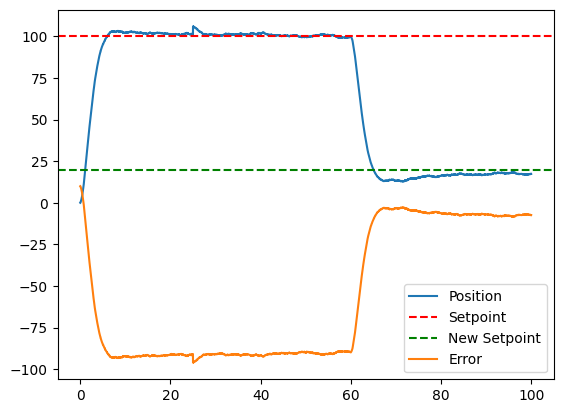

In [115]:
from simple_pid import PID
from matplotlib import pyplot as plt
import numpy as np

# Setup PID controller
pid = PID(0.5, 0.02, 0.4, setpoint=100) # Trying to get to 100m position
pid.sample_time = 0.01 # Update every 0.01 seconds

dt = 0.01 # Match the sample time
position = 0
velocity = 0

times, positions, errors = [], [], []

# Simulation loop
for i in range(10000): # 10000 steps = 10 seconds
    t = i * dt # Current time

    control = pid(position + (np.random.randn() * 10), dt=dt) # Get control output from PID with noise
    velocity += (control - 0.8 * velocity - 3.7) * dt    # Correction acts as acceleration
    position += velocity * dt    # Update position based on velocity

    if (i == 2500):
        position += 5 # Disturbance at 2.5 seconds
    
    if (i == 6000):
        pid.setpoint = 20 # Change setpoint at 6 seconds

    times.append(t)
    positions.append(position)
    errors.append(10 - position) # Error is setpoint - position


# Plot results
plt.plot(times,positions,label='Position')
plt.axhline(100, color='r', linestyle='--', label='Setpoint')
plt.axhline(20, color='g', linestyle='--', label='New Setpoint')
plt.plot(times,errors,label='Error')
plt.legend()
plt.show()

<h1>Velocity Correction System </h1>
Now, velocity will be the measurement to focus on correction. The object will now start at a velocity of 5m/s and trying to reach 80m/s. 

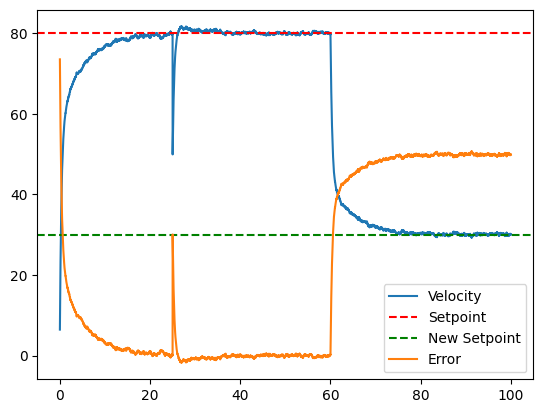

In [127]:
# Setup PID controller
pid = PID(2, 0.5, 0, setpoint=80) # Trying to get to 80m/s
pid.sample_time = 0.01 # Update every 0.01 seconds

dt = 0.01 # Match the sample time
position = 0
velocity = 5

times, velocities, errors = [], [], []

# Simulation loop
for i in range(10000): # 10000 steps = 10 seconds
    t = i * dt # Current time

    control = pid(velocity + (np.random.randn() * 3), dt=dt) # Get control output from PID with noise
    velocity += (control - 0.8 * velocity - 3.7) * dt    # Correction acts as acceleration
    position += velocity * dt    # Update position based on velocity

    if (i == 2500):
        velocity -= 30 # Disturbance at 5 seconds, hit a road bump
    
    if (i == 6000):
        pid.setpoint = 30 # Change setpoint at 6 seconds



    times.append(t)
    velocities.append(velocity)
    errors.append(80 - velocity) # Error is setpoint - velocity


# Plot results
plt.plot(times,velocities,label='Velocity')
plt.axhline(80, color='r', linestyle='--', label='Setpoint')
plt.axhline(30, color='g', linestyle='--', label='New Setpoint')
plt.plot(times,errors,label='Error')
plt.legend()
plt.show()

<h1>Temperature Sensor For Heat</h1>
Now, instead of an object moving now I will simulate a heating system. The system will start at an ambient temperature then the PID control system will attempt to heat the system to 73C. At 5s someone accidentally opens the seal and the temperature quickly drops by 5C. Random noise is also injected. 

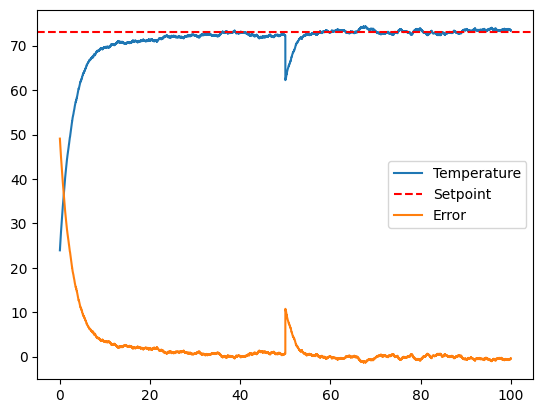

In [53]:
pid = PID(0.7,0.05,0, setpoint=73) # 73C is setpoint
pid.sample_time = 0.01

dt = 0.01
temp = 23.73 # Starting at ambient temp
heating_rate = 0.5
cooling_rate = 0.1
ambient_temp = 23.73

times, temps, errors = [], [], []

for i in range(10000):
    t = i * dt
    control = pid(temp + (np.random.randn() * 10), dt=dt)

    # Heater pushes temp up
    temp += (control * heating_rate) * dt
    # Environment pulls temp down
    temp -= (temp - ambient_temp) * cooling_rate * dt

    if (i == 5000):
        temp -= 10 # Disturbance at 5 seconds, seal leak!

    times.append(t)
    temps.append(temp)
    errors.append(73 - temp)


plt.plot(times, temps, label='Temperature')
plt. axhline(73, color='r', linestyle='--', label='Setpoint')
plt.plot(times, errors, label='Error')
plt.legend()
plt.show()

<h1>Temperature Sensor Cooling </h1>
Now to practice using the PID control in reverse mode, a cooling system will be modeled. Again the system will start at ambient temperature, then the PID control will attempt to cool it to 5C. Again, an intern accidentally opens the seal and the temperature jumps up 10C quickly and the system must compensate. 

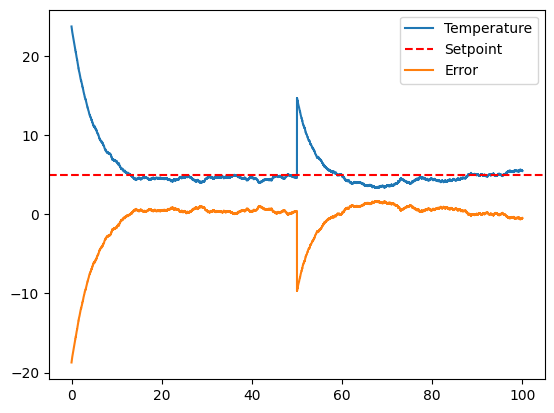

In [103]:
pid = PID(-4,-0.3, 0, setpoint=5) # 5C is setpoint
pid.sample_time = 0.01

dt = 0.01
temp = 23.73 # Starting at ambient temp
cooling_rate = 0.05
ambient_temp = 23.73

times, temps, errors = [], [], []

for i in range(10000):
    t = i * dt
    control = pid(temp + (np.random.randn() * 10), dt=dt)

    # Cooler pushes temp down
    temp -= (control * cooling_rate) * dt
    # Environment pulls temp up
    temp -= (temp - ambient_temp) * cooling_rate * dt

    if (i == 5000):
        temp += 10 # Disturbance at 5 seconds, seal leak!

    times.append(t)
    temps.append(temp)
    errors.append(5 - temp)


plt.plot(times, temps, label='Temperature')
plt. axhline(5, color='r', linestyle='--', label='Setpoint')
plt.plot(times, errors, label='Error')
plt.legend()
plt.show()